# Bayesian-CVaR ETF allocation with risk-timing overlays — Results

**Running this notebook RE-RUNS THE MODEL on your machine** and then builds every result from *your*
run — it does not just read precomputed numbers.

*Kernel -> Restart & Run All* will:
1. **Step 0** — run the model engine in `scripts/` on the raw inputs in `datasets/`, regenerating the two
   base arms (`main_dyn_off`, `main_dyn_strong`) into `data/` **on this machine** (takes a few minutes).
2. derive the realized-vol / model-CVaR / combined **overlay arms**, the **1/N & Markowitz** benchmarks,
   all metrics, the significance tests, and all charts.

Requirements: `pip install -r requirements.txt`, and run from the `FINAL/` folder. To skip the model
re-run and just look at the existing `data/`, set `REGENERATE = False` in Step 0.

In [2]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import norm, skew, kurtosis
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
import matplotlib.pyplot as plt, matplotlib.dates as mdates
import report_style as rs; rs.apply()
pd.set_option("display.width", 240); pd.set_option("display.max_columns", 40)

DATA = Path("results"); DAILY_FILE = Path("datasets")/"excel"/"new_etf_returns.csv"
RF = 0.02; CAP = 0.12; LB_Y = 3; SEED = 42
KMIN, KMAX = 0.30, 1.00; SPAN, TARGET_VOL = 21, 0.12; TOP_K = 16; N_TRIALS = 40
CAT = ["#2E86C1","#3CA370","#F5A623","#C94C4C","#163A5F","#6FB7E0","#7FC9A6","#F7C271",
       "#D98A8A","#4E6E8E","#A6CEE3","#8E5BA6","#B5BD68","#E08AB0","#56A8A8","#C08457"]
print("config loaded")


config loaded


## Step 0 — run the model from scratch (on this machine)

This runs the walk-forward Bayesian-CVaR backtest for the two base arms and writes the results into
`data/`. It reads `datasets/` and the engine in `scripts/`. Set `REGENERATE = False` to skip and reuse
whatever is already in `data/`.

In [3]:
REGENERATE = True   # True -> re-run the model here; False -> use existing data/ (fast, view only)
RUNS = [
    ("scripts.runs.run", "main_dyn_off.yaml"),
    ("scripts.runs.run", "main_dyn_strong.yaml"),
    ("scripts.runs.run", "advanced_smart_bayesian.yaml"),
    # strategy_smart.yaml uses strategy_run.py, not run.py
    # ("scripts.runs.strategy_run", "strategy_smart.yaml"),
]
if REGENERATE:
    import subprocess, sys, os, shutil, time
    HERE = Path.cwd(); env = os.environ.copy(); env["PYTHONPATH"] = str(HERE); t0 = time.time()
    for module, cfg in RUNS:
        print(f"running the model on THIS machine: {cfg}  (a few minutes) ...", flush=True)
        r = subprocess.run(
            [sys.executable, "-m", module, "-c", cfg],
            cwd=str(HERE),
            env=env,
            capture_output=True,
            text=True
        )
        if r.returncode != 0:
            print("STDOUT tail:\n", (r.stdout or "")[-1500:]); print("STDERR tail:\n", (r.stderr or "")[-1500:])
            raise RuntimeError(f"model run failed for {cfg} -- check requirements.txt and that datasets/ is present")
        print(f"  done: {cfg}")
    need = {"main_dyn_off": ["pnl.csv","weights.xlsx","real.csv"],
            "main_dyn_strong": ["pnl.csv","weights.xlsx","real.csv","forecast_risk.csv","dynamic_parameter_history.csv"]}
    for arm, files in need.items():                       # copy-with-retry (Windows-safe; avoids locked-file rmtree)
        (HERE/"data"/arm).mkdir(parents=True, exist_ok=True)
        for f in files:
            for _ in range(6):
                try: shutil.copy2(HERE/"results"/arm/f, HERE/"data"/arm/f); break
                except PermissionError: time.sleep(1.0)
    # shutil.rmtree(HERE/"results", ignore_errors=True)
    print(f"model re-run complete in {time.time()-t0:.0f}s -> data/ REGENERATED on this machine (not precomputed)")
else:
    print("REGENERATE = False -> using the base arms already in data/")


running the model on THIS machine: main_dyn_off.yaml  (a few minutes) ...
  done: main_dyn_off.yaml
running the model on THIS machine: main_dyn_strong.yaml  (a few minutes) ...
  done: main_dyn_strong.yaml
running the model on THIS machine: advanced_smart_bayesian.yaml  (a few minutes) ...
  done: advanced_smart_bayesian.yaml
model re-run complete in 578s -> data/ REGENERATED on this machine (not precomputed)


## 1. Load the (freshly produced) base arms, derive overlays, build benchmarks

In [4]:
PRIMARY_STATIC = "main_dyn_off"
PRIMARY_DYNAMIC = "main_dyn_strong"
SMART_BAYESIAN = "advanced_smart_bayesian"
SMART_STRATEGY = "strategy_smart_liquidity_weighted"
DATA = Path("results")

def load_pnl_full(arm):
    p = pd.read_csv(DATA/arm/"pnl.csv"); c = p.columns[0]; p[c] = pd.to_datetime(p[c])
    return p.set_index(c)["Returns"].astype(float)
def load_pnl(arm): return load_pnl_full(arm).iloc[1:]

def load_weights(arm):
    xl = pd.ExcelFile(DATA/arm/"weights.xlsx"); out = {}
    for sh in xl.sheet_names:
        d = xl.parse(sh)
        if "weights" not in d.columns: continue
        w = pd.to_numeric(d["weights"], errors="coerce").fillna(0.0)
        s = pd.Series(w.values, index=d[d.columns[0]].astype(str).values); s = s[s > 1e-9]
        if not s.empty:
            try: out[pd.to_datetime(sh)] = s/s.sum()
            except Exception: pass
    return dict(sorted(out.items()))

# _need = set(pd.read_csv(DATA/PRIMARY_STATIC/"real.csv", nrows=0).columns) - {"Unnamed: 0"}
# try: _need |= set(pd.read_csv(DATA/PRIMARY_DYNAMIC/"real.csv", nrows=0).columns) - {"Unnamed: 0"}
# except Exception: pass
# _need.add("SPY")
_need = set()
for arm in [PRIMARY_STATIC, PRIMARY_DYNAMIC, SMART_BAYESIAN, SMART_STRATEGY]:
    p = DATA / arm / "real.csv"
    if p.exists():
        _need |= set(pd.read_csv(p, nrows=0).columns) - {"Unnamed: 0"}

_need.add("SPY")
def daily_simple():
    head = pd.read_csv(DAILY_FILE, nrows=0).columns
    use = ["Date"] + [c for c in head if c in _need]
    df = pd.read_csv(DAILY_FILE, usecols=use); df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()
    return np.exp(df.apply(pd.to_numeric, errors="coerce")) - 1.0
DLY = daily_simple()

W_strong = load_weights(PRIMARY_DYNAMIC); r_strong_full = load_pnl_full(PRIMARY_DYNAMIC); idx = r_strong_full.index
reb = list(W_strong.keys()); parts = []
for i in range(len(reb)-1):
    d0, d1 = reb[i], reb[i+1]; w = W_strong[d0]; cc = [t for t in w.index if t in DLY.columns]
    win = DLY.loc[(DLY.index > d0) & (DLY.index <= d1), cc].fillna(0.0)
    if not win.empty: parts.append(pd.Series(win.values @ w.reindex(cc).values, index=win.index))
port_daily = pd.concat(parts).sort_index(); va = port_daily.rolling(SPAN, min_periods=10).std()*np.sqrt(252)
k_rv = pd.Series({idx[j]: (float(np.clip(TARGET_VOL/va.asof(idx[j-1]), KMIN, KMAX))
                  if (va.asof(idx[j-1]) == va.asof(idx[j-1]) and va.asof(idx[j-1]) > 0) else KMAX)
                  for j in range(1, len(idx))})
rs_ret = r_strong_full.iloc[1:]
fc = pd.read_csv(DATA/PRIMARY_DYNAMIC/"forecast_risk.csv"); fc["date"] = pd.to_datetime(fc["date"])
cv = fc.set_index("date")["cvar_model"].astype(float).reindex(rs_ret.index)
k_mc = (cv.expanding(min_periods=6).median().bfill()/cv).clip(KMIN, KMAX)
k_rv = k_rv.reindex(rs_ret.index); k_comb = (k_rv*k_mc).clip(KMIN, KMAX)
r_vt   = k_rv*rs_ret   + (1-k_rv)*RF/12
r_mc   = k_mc*rs_ret   + (1-k_mc)*RF/12
r_comb = k_comb*rs_ret + (1-k_comb)*RF/12

def solve(mu, cov, kind):
    n = len(mu); x0 = np.ones(n)/n; bnds = [(0.0, CAP)]*n; cons = [{"type":"eq","fun":lambda w: w.sum()-1.0}]
    obj = (lambda w: float(w@cov@w)) if kind == "minvar" else (lambda w: -float((mu@w - RF/12)/np.sqrt(max(w@cov@w,1e-12))))
    r = minimize(obj, x0, method="SLSQP", bounds=bnds, constraints=cons, options={"maxiter":300,"ftol":1e-9})
    w = r.x if (r.success and np.all(np.isfinite(r.x))) else x0; w = np.clip(w, 0, CAP)
    return w/w.sum() if w.sum() > 0 else x0

def benchmarks():
    real = pd.read_csv(DATA/PRIMARY_STATIC/"real.csv"); real["Unnamed: 0"] = pd.to_datetime(real["Unnamed: 0"])
    real = real.set_index("Unnamed: 0"); real_s = np.exp(real)-1.0; dts = list(real.index)
    ew, msr, mv = [], [], []
    for i in range(1, len(dts)):
        rd, bd = dts[i], dts[i-1]; elig = real_s.loc[rd].dropna().index.tolist()
        win = DLY.loc[(DLY.index > bd - pd.DateOffset(years=LB_Y)) & (DLY.index <= bd)]
        good = [t for t in elig if t in win.columns and win[t].notna().sum() >= 250] or [t for t in elig if t in win.columns]
        if len(good) < 5: continue
        rr = real_s.loc[rd, good].astype(float); W = win[good].dropna(how="all"); mu = W.mean().values*21.0
        cov = (LedoitWolf().fit(np.nan_to_num(W.values)).covariance_ if W.shape[0] > len(good) else np.cov(np.nan_to_num(W.values), rowvar=False))*21.0
        cov = np.atleast_2d(cov)
        ew.append((rd, float((np.ones(len(good))/len(good)) @ rr.values)))
        msr.append((rd, float(solve(mu, cov, "ms") @ rr.values)))
        mv.append((rd, float(solve(mu, cov, "minvar") @ rr.values)))
    return {"Benchmark 1/N": pd.Series(dict(ew)),
            "Benchmark Markowitz max-Sharpe": pd.Series(dict(msr)),
            "Benchmark Markowitz min-variance": pd.Series(dict(mv))}

arms = {
    "Static (no overlay)": load_pnl(PRIMARY_STATIC),
    "Dynamic base": rs_ret,
    "+ Realized-vol overlay": r_vt,
    "+ Model-CVaR overlay": r_mc,
    "+ Combined (managed)": r_comb,
}
# Add updated smart Bayesian run
if (DATA / SMART_BAYESIAN / "pnl.csv").exists():
    arms["+ Advanced smart Bayesian"] = load_pnl(SMART_BAYESIAN)

# Add strategy-only smart run
if (DATA / SMART_STRATEGY / "pnl.csv").exists():
    arms["+ Smart strategy"] = load_pnl(SMART_STRATEGY)
arms.update(benchmarks())
print("arms built (months each):", {k: len(v) for k, v in arms.items()})
print(f"exposure k: realized-vol median {k_rv.median():.2f}, model-CVaR median {k_mc.median():.2f}, "
      f"combined median {k_comb.median():.2f} | corr(k_rv,k_mc)={np.corrcoef(k_rv,k_mc)[0,1]:+.2f}")


arms built (months each): {'Static (no overlay)': 83, 'Dynamic base': 83, '+ Realized-vol overlay': 83, '+ Model-CVaR overlay': 83, '+ Combined (managed)': 83, '+ Advanced smart Bayesian': 83, 'Benchmark 1/N': 83, 'Benchmark Markowitz max-Sharpe': 83, 'Benchmark Markowitz min-variance': 83}
exposure k: realized-vol median 0.58, model-CVaR median 0.91, combined median 0.43 | corr(k_rv,k_mc)=+0.34


## 2. Metrics table — all strategies, all ratios

Monthly excess returns (RF = 2%). `Beta`/`Treynor` use SPY; `PSR`/`DSR` are the Probabilistic and
Deflated Sharpe ratios (DSR dispersion over the strategy arms only, conservative N = 40 trials).

In [5]:
spy = DLY["SPY"]
full_idx = list(load_pnl_full(PRIMARY_STATIC).index)
def spy_monthly(ix):
    out = {}
    for j in range(1, len(ix)):
        d0, d1 = ix[j-1], ix[j]; w = spy[(spy.index > d0) & (spy.index <= d1)]
        out[d1] = float(np.prod(1+w.values)-1) if len(w) else np.nan
    return pd.Series(out)
MKT = spy_monthly(full_idx)

def ann_sharpe(r): r = np.asarray(r, float); ex = r - RF/12; return ex.mean()/ex.std(ddof=1)*np.sqrt(12)
def max_dd(r): r = np.asarray(r, float); eq = np.cumprod(1+r); return float((eq/np.maximum.accumulate(eq)-1).min())

def metrics(r):
    r = r.dropna(); rv = np.asarray(r, float); n = len(rv); tot = float(np.prod(1+rv)-1); ann = (1+tot)**(12/n)-1
    vol = rv.std(ddof=1)*np.sqrt(12); ex = rv - RF/12; sh = ex.mean()/ex.std(ddof=1)*np.sqrt(12)
    dn = rv[rv < 0]; ddv = dn.std(ddof=1)*np.sqrt(12) if len(dn) > 1 else np.nan
    sor = (ann - RF)/ddv if (ddv and ddv > 0) else np.nan
    eq = np.cumprod(1+rv); dr = eq/np.maximum.accumulate(eq)-1; mdd = float(dr.min())
    cal = ann/abs(mdd) if mdd < 0 else np.nan; v95 = np.percentile(rv, 5); cv = float(rv[rv <= v95].mean())
    m = MKT.reindex(r.index); beta = np.cov(rv, m.values, ddof=1)[0,1]/np.var(m.values, ddof=1)
    treyn = (ann - RF)/beta*100; ddev = np.sqrt(np.mean(np.minimum(rv,0)**2))*np.sqrt(12)*100
    pain = -dr.mean(); painr = (ann - RF)/pain if pain > 0 else np.nan; mad = np.mean(np.abs(rv - rv.mean()))*100
    return dict(Cumul=tot*100, Ann=ann*100, Vol=vol*100, Sharpe=sh, Sortino=sor, MaxDD=mdd*100, Calmar=cal,
                CVaR95=cv*100, Beta=beta, Treynor=treyn, DownDev=ddev, PainRatio=painr, MAD=mad,
                _sk=float(skew(rv)), _ku=float(kurtosis(rv, fisher=False)), _n=n, _srm=float(ex.mean()/ex.std(ddof=1)))

def psr(srm, star, n, sk, ku):
    den = np.sqrt(max(1 - sk*srm + (ku-1)/4*srm**2, 1e-12)); return float(norm.cdf((srm - star)*np.sqrt(n-1)/den))

ms = {k: metrics(v) for k, v in arms.items()}
g = 0.5772156649
var_srm = np.var(np.array([m["Sharpe"] for k, m in ms.items() if not k.startswith("Benchmark")])/np.sqrt(12), ddof=1)
z = (1-g)*norm.ppf(1-1/N_TRIALS) + g*norm.ppf(1-1/(N_TRIALS*np.e)); star = float(np.sqrt(max(var_srm,0))*z)

cols = ["Cumul","Ann","Vol","Sharpe","Sortino","MaxDD","Calmar","CVaR95","Beta","Treynor","DownDev","PainRatio","MAD"]
rows = {}
for k, m in ms.items():
    d = {c: m[c] for c in cols}
    d["PSR"] = psr(m["_srm"], 0.0, m["_n"], m["_sk"], m["_ku"])*100
    d["DSR"] = psr(m["_srm"], star, m["_n"], m["_sk"], m["_ku"])*100
    rows[k] = d
TBL = pd.DataFrame(rows).T[cols + ["PSR","DSR"]].round(2)
TBL.columns = ["Cumul %","Ann %","Vol %","Sharpe","Sortino","MaxDD %","Calmar","CVaR95 %","Beta",
               "Treynor %","DownDev %","Pain ratio","MAD %","PSR %","DSR %"]
TBL


,Cumul %,Ann %,Vol %,Sharpe,Sortino,MaxDD %,Calmar,CVaR95 %,Beta,Treynor %,DownDev %,Pain ratio,MAD %,PSR %,DSR %
Static (no overlay),162.09,14.95,20.78,0.68,1.11,-15.15,0.99,-10.76,0.85,15.27,12.08,3.87,4.79,96.05,89.59
Dynamic base,157.82,14.67,20.99,0.66,1.05,-15.81,0.93,-10.92,0.84,15.02,12.21,3.72,4.77,95.73,88.89
+ Realized-vol overlay,114.29,11.65,11.61,0.84,1.85,-9.28,1.26,-4.53,0.46,21.05,5.88,5.42,2.72,98.75,95.79
+ Model-CVaR overlay,134.27,13.10,16.98,0.69,1.08,-15.10,0.87,-8.96,0.65,17.10,9.92,4.53,3.85,96.26,90.10
+ Combined (managed),104.98,10.93,10.27,0.87,1.92,-9.28,1.18,-4.05,0.39,22.80,5.03,6.53,2.36,99.09,96.70
+ Advanced smart Bayesian,161.81,14.93,19.46,0.71,1.10,-14.87,1.00,-10.48,0.79,16.35,11.72,4.39,4.25,96.54,90.75
Benchmark 1/N,98.35,10.41,14.44,0.62,0.81,-21.36,0.49,-8.71,0.77,10.91,9.31,1.91,3.15,93.71,85.47
Benchmark Markowitz max-Sharpe,26.02,3.40,5.57,0.27,0.26,-15.45,0.22,-3.85,0.22,6.23,4.06,0.36,1.08,75.03,57.68
Benchmark Markowitz min-variance,14.65,2.00,1.68,-0.00,-0.00,-5.18,0.39,-1.30,0.06,-0.07,1.26,-0.00,0.32,49.50,30.26


## 3. Statistical significance — paired bootstrap (5,000 resamples)

In [6]:
rng = np.random.default_rng(SEED); B = 5000
def boot(base, treat, lbl):
    j = base.index.intersection(treat.index); a, b = base.loc[j].values, treat.loc[j].values; n = len(j)
    shd = np.empty(B); ddd = np.empty(B)
    for k in range(B):
        ix = rng.integers(0, n, n); shd[k] = ann_sharpe(b[ix]) - ann_sharpe(a[ix]); ddd[k] = max_dd(b[ix]) - max_dd(a[ix])
    print(f"  {lbl:26s} dSharpe={ann_sharpe(b)-ann_sharpe(a):+.3f}  P(better)={float((shd>0).mean()):.3f}   "
          f"dMaxDD={max_dd(b)-max_dd(a):+.3f}  P(shallower)={float((ddd>0).mean()):.3f}")
print("Paired bootstrap (5000), treatment = Combined (managed)")
boot(arms["+ Realized-vol overlay"], arms["+ Combined (managed)"], "vs Realized-vol overlay")
boot(arms["Benchmark 1/N"],          arms["+ Combined (managed)"], "vs 1/N")
boot(arms["Dynamic base"],           arms["+ Combined (managed)"], "vs Dynamic base")
print(f"\nCombined PSR = {TBL.loc['+ Combined (managed)','PSR %']:.1f}%   DSR = {TBL.loc['+ Combined (managed)','DSR %']:.1f}%")


Paired bootstrap (5000), treatment = Combined (managed)
  vs Realized-vol overlay    dSharpe=+0.033  P(better)=0.677   dMaxDD=+0.000  P(shallower)=0.956
  vs 1/N                     dSharpe=+0.248  P(better)=0.786   dMaxDD=+0.121  P(shallower)=0.957
  vs Dynamic base            dSharpe=+0.206  P(better)=0.921   dMaxDD=+0.065  P(shallower)=1.000

Combined PSR = 99.1%   DSR = 96.7%


## 4. Cumulative performance

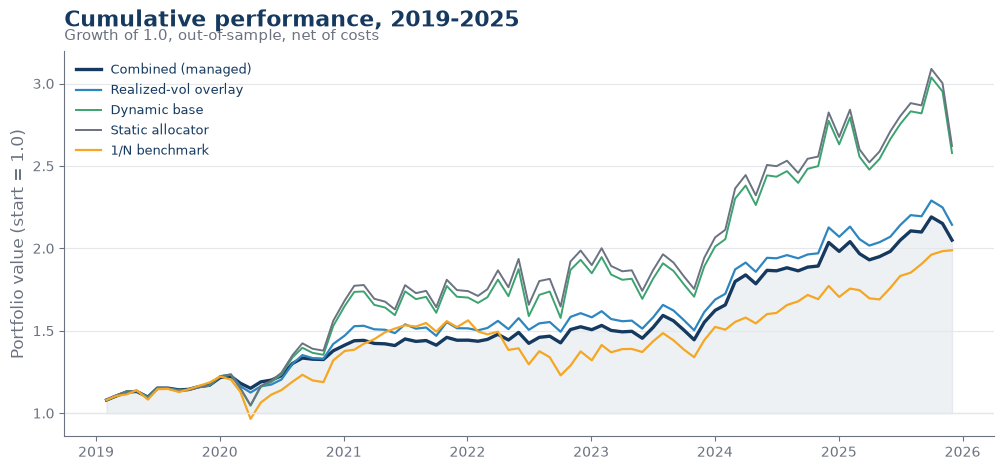

In [7]:
def oneN():
    real = pd.read_csv(DATA/PRIMARY_STATIC/"real.csv"); real["Unnamed: 0"] = pd.to_datetime(real["Unnamed: 0"])
    real = real.set_index("Unnamed: 0"); rsx = np.exp(real)-1.0
    return pd.Series({d: float(rsx.loc[d].dropna().mean()) for d in rsx.index[1:]})
series = {"Combined (managed)": (arms["+ Combined (managed)"], rs.NAVY, 2.4),
          "Realized-vol overlay": (arms["+ Realized-vol overlay"], rs.BLUE, 1.6),
          "Dynamic base": (arms["Dynamic base"], rs.GREEN, 1.4),
          "Static allocator": (arms["Static (no overlay)"], rs.GREY, 1.4),
          "1/N benchmark": (oneN(), rs.ORANGE, 1.6)}
fig, ax = plt.subplots(figsize=(12, 5))
for lbl, (r, col, lw) in series.items():
    eq = (1+r).cumprod()
    if lbl == "Combined (managed)": ax.fill_between(eq.index, 1, eq.values, color=rs.NAVY, alpha=0.07)
    ax.plot(eq.index, eq.values, color=col, lw=lw, label=lbl)
ax.axhline(1, color=rs.GRID, lw=1); ax.set_ylabel("Portfolio value (start = 1.0)"); ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
rs.title(ax, "Cumulative performance, 2019-2025", "Growth of 1.0, out-of-sample, net of costs")
plt.show()


## 5. Drawdowns (underwater curve)

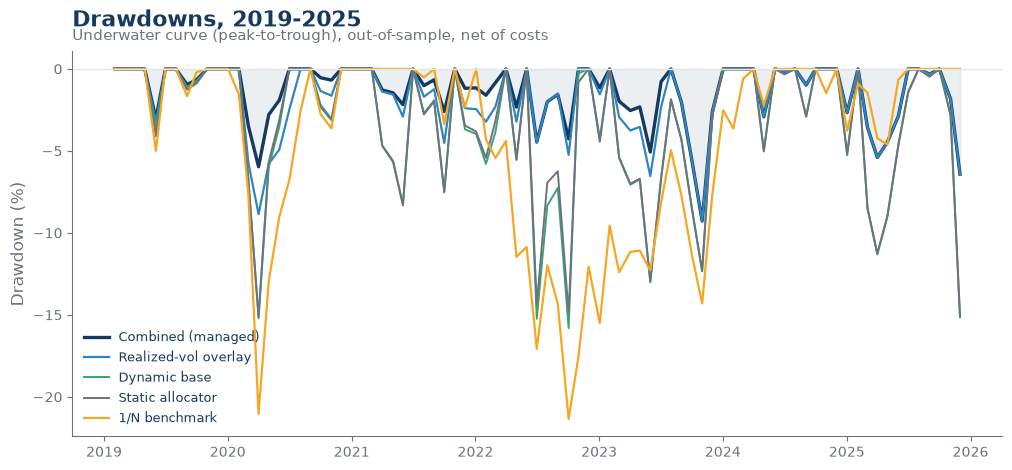

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
for lbl, (r, col, lw) in series.items():
    eq = (1+r).cumprod(); dd = (eq/eq.cummax()-1)*100
    if lbl == "Combined (managed)": ax.fill_between(dd.index, 0, dd.values, color=rs.NAVY, alpha=0.08)
    ax.plot(dd.index, dd.values, color=col, lw=lw, label=lbl)
ax.axhline(0, color=rs.GRID, lw=1); ax.set_ylabel("Drawdown (%)"); ax.grid(axis="y"); ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
rs.title(ax, "Drawdowns, 2019-2025", "Underwater curve (peak-to-trough), out-of-sample, net of costs")
plt.show()


## 6. Portfolio composition and concentration

Held ETFs / month:
  Static  -> mean 91.9, median 47, min 36, max 218
  Managed -> mean 92.6, median 49, min 36, max 218


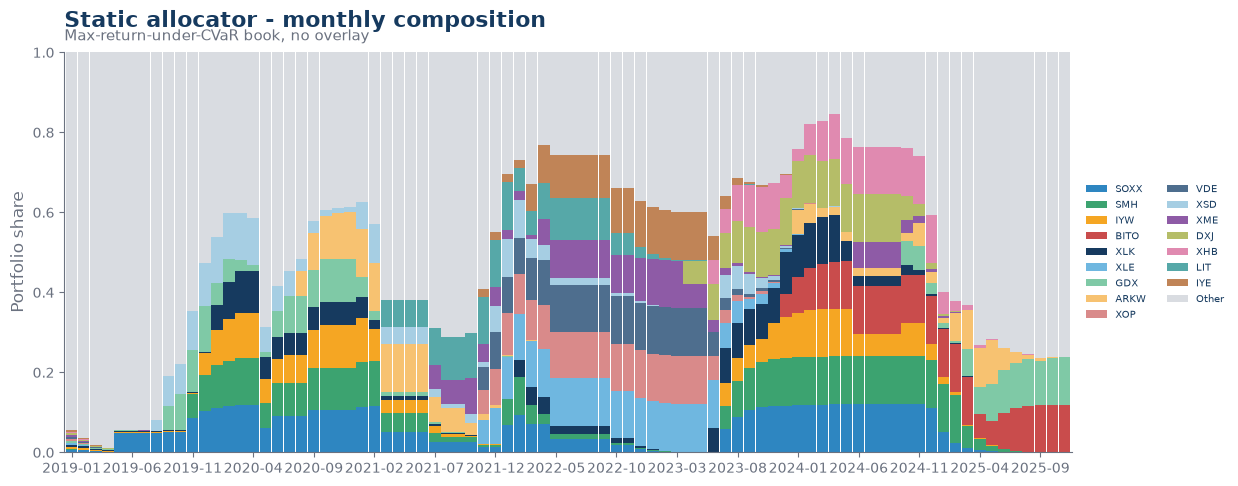

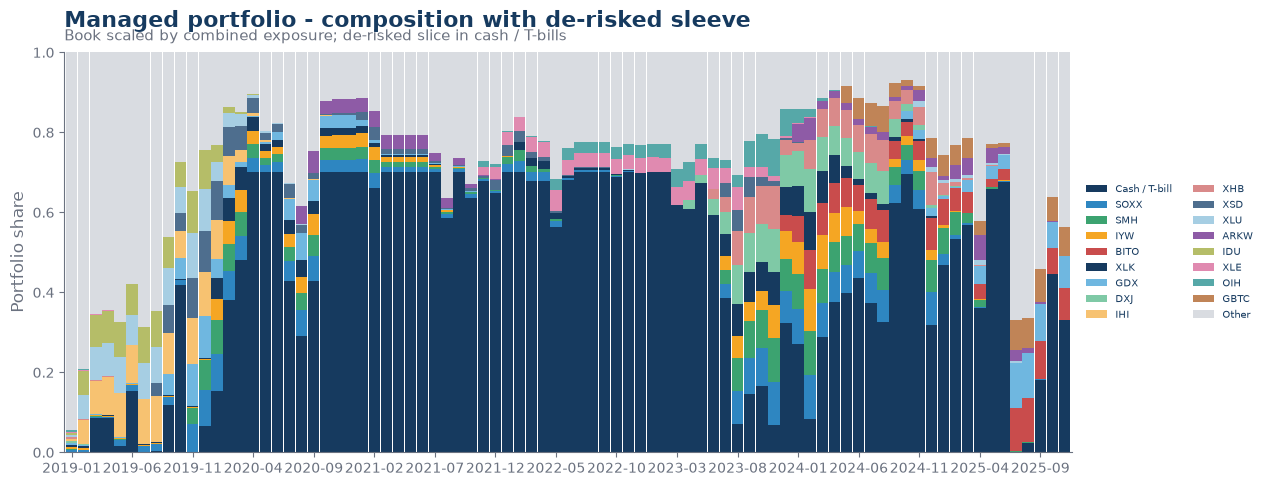

In [9]:
w_static = load_weights(PRIMARY_STATIC); w_strong = W_strong
def comp_matrix(weights, kt=None):
    months = sorted(weights.keys()); colset = sorted({t for m in months for t in weights[m].index})
    M = pd.DataFrame(0.0, index=months, columns=colset)
    for m in months:
        M.loc[m, weights[m].index] = weights[m].values
        if kt is not None: M.loc[m] *= float(kt.get(m, 1.0))
    if kt is not None: M["Cash / T-bill"] = (1.0 - M.sum(axis=1)).clip(lower=0)
    return M
def plot_comp(M, title, sub, cash="Cash / T-bill"):
    etfs = [c for c in M.columns if c != cash]
    keep = list(M[etfs].sum().sort_values(ascending=False).head(TOP_K).index); rest = [c for c in etfs if c not in keep]
    P = M[keep].copy()
    if rest: P["Other"] = M[rest].sum(axis=1)
    order = keep + (["Other"] if rest else []); cmap = {c: CAT[i % len(CAT)] for i, c in enumerate(keep)}
    if rest: cmap["Other"] = "#D9DCE1"
    if cash in M.columns: P[cash] = M[cash]; order = [cash] + order; cmap[cash] = rs.NAVY
    x = np.arange(len(P.index)); bottom = np.zeros(len(P.index)); fig, ax = plt.subplots(figsize=(13, 5.2))
    for c in order:
        ax.bar(x, P[c].values, bottom=bottom, width=0.95, color=cmap[c], label=c, linewidth=0); bottom += P[c].values
    step = max(1, len(x)//14); ax.set_xticks(x[::step]); ax.set_xticklabels([d.strftime("%Y-%m") for d in P.index[::step]])
    ax.set_xlim(-0.6, len(x)-0.4); ax.set_ylim(0, 1.001); ax.set_ylabel("Portfolio share"); ax.grid(False)
    ax.legend(ncol=2, fontsize=7.5, loc="center left", bbox_to_anchor=(1.005, 0.5)); rs.title(ax, title, sub); plt.show()

ns = pd.Series({m: int((w > 1e-9).sum()) for m, w in w_static.items()}); ns = ns[ns.index >= "2019-01-01"]
nm = pd.Series({m: int((w > 1e-9).sum()) for m, w in w_strong.items()}); nm = nm[nm.index >= "2019-01-01"]
print("Held ETFs / month:")
print(f"  Static  -> mean {ns.mean():.1f}, median {int(ns.median())}, min {ns.min()}, max {ns.max()}")
print(f"  Managed -> mean {nm.mean():.1f}, median {int(nm.median())}, min {nm.min()}, max {nm.max()}")
plot_comp(comp_matrix(w_static), "Static allocator - monthly composition", "Max-return-under-CVaR book, no overlay")
plot_comp(comp_matrix(w_strong, k_comb), "Managed portfolio - composition with de-risked sleeve",
          "Book scaled by combined exposure; de-risked slice in cash / T-bills")


## 7. Turnover

Turnover (one-way): mean 12.6%, median 11.5%, max 39.4%, zero-turnover 3/82 months, large(>=10%) 49


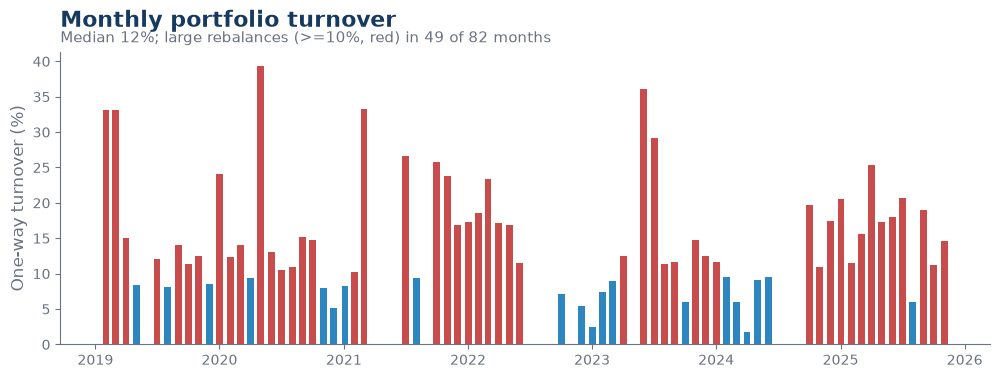

In [10]:
allm = sorted(w_strong.keys()); tn = {}
for i in range(1, len(allm)):
    if allm[i] < pd.Timestamp("2019-01-01"): continue
    a, b = w_strong[allm[i-1]], w_strong[allm[i]]; ixu = a.index.union(b.index)
    tn[allm[i]] = float(np.abs(b.reindex(ixu).fillna(0) - a.reindex(ixu).fillna(0)).sum())/2
tn = pd.Series(tn)
print(f"Turnover (one-way): mean {tn.mean()*100:.1f}%, median {tn.median()*100:.1f}%, max {tn.max()*100:.1f}%, "
      f"zero-turnover {int((tn<1e-9).sum())}/{len(tn)} months, large(>=10%) {int((tn>=0.10).sum())}")
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.bar(tn.index, tn.values*100, width=20, color=[rs.RED if v >= 0.10 else rs.BLUE for v in tn.values], linewidth=0)
ax.set_ylabel("One-way turnover (%)"); ax.grid(axis="y")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
rs.title(ax, "Monthly portfolio turnover", f"Median {tn.median()*100:.0f}%; large rebalances (>=10%, red) in {int((tn>=0.10).sum())} of {len(tn)} months")
plt.show()


## 8. Dynamic optimiser parameters

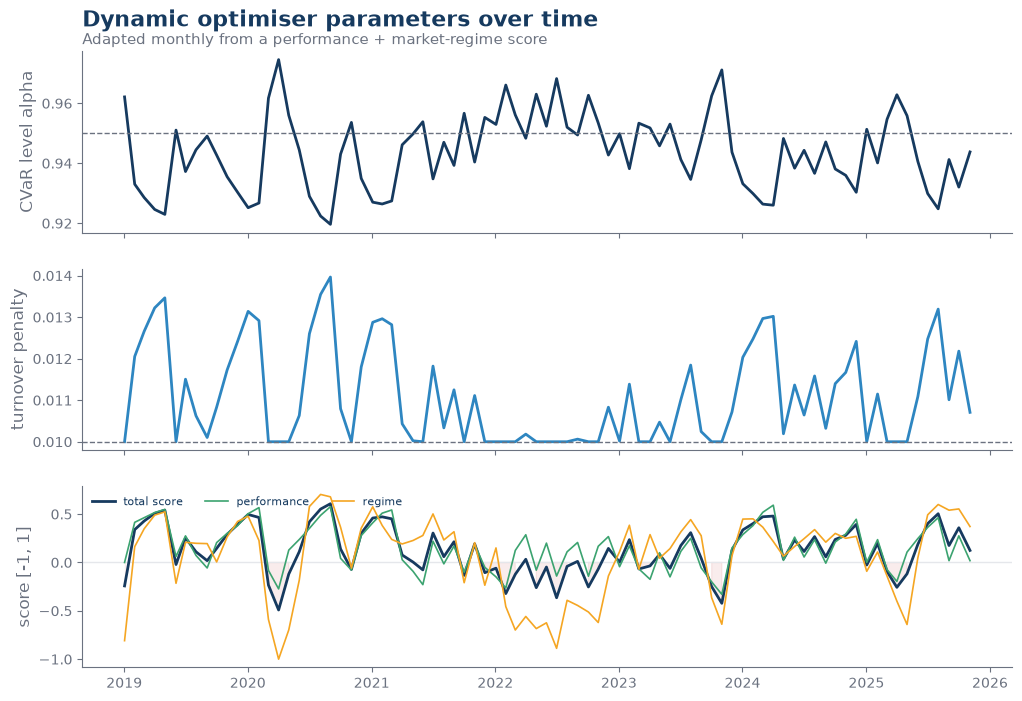

alpha range [0.920, 0.975] | lambda range [0.0100, 0.0140] | score range [-0.49, 0.61]


In [11]:
h = pd.read_csv(DATA/"main_dyn_strong"/"dynamic_parameter_history.csv"); h["date"] = pd.to_datetime(h["date"])
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
ax[0].plot(h["date"], h["confidence_level"], color=rs.NAVY, lw=2); ax[0].axhline(0.95, color=rs.GREY, ls="--", lw=1)
ax[0].set_ylabel("CVaR level alpha"); rs.title(ax[0], "Dynamic optimiser parameters over time", "Adapted monthly from a performance + market-regime score")
ax[1].plot(h["date"], h["turnover_penalty"], color=rs.BLUE, lw=2); ax[1].axhline(0.01, color=rs.GREY, ls="--", lw=1); ax[1].set_ylabel("turnover penalty")
ax[2].axhline(0, color=rs.GRID, lw=1)
ax[2].plot(h["date"], h["total_score"], color=rs.NAVY, lw=2, label="total score")
ax[2].plot(h["date"], h["performance_score"], color=rs.GREEN, lw=1.2, label="performance")
ax[2].plot(h["date"], h["regime_score"], color=rs.ORANGE, lw=1.2, label="regime")
ax[2].fill_between(h["date"], 0, h["total_score"], where=h["total_score"] < 0, color=rs.RED, alpha=0.10)
ax[2].set_ylabel("score [-1, 1]"); ax[2].legend(loc="upper left", fontsize=8, ncol=3)
for a in ax: a.grid(axis="y")
ax[2].xaxis.set_major_locator(mdates.YearLocator()); ax[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()
print(f"alpha range [{h.confidence_level.min():.3f}, {h.confidence_level.max():.3f}] | "
      f"lambda range [{h.turnover_penalty.min():.4f}, {h.turnover_penalty.max():.4f}] | "
      f"score range [{h.total_score.min():.2f}, {h.total_score.max():.2f}]")
